In [1]:
import sys, json, yaml
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "/home2/s4636708/master_thesis_project/src")
from galaxy_sidm.mock.residuals import pv_residuals, cube_residuals

MARTINI = Path("/scratch/s4636708/aida/derived/martini")
CALIBRATION = "/home2/s4636708/master_thesis_project/config/residual_calibration.yaml"
ASYMMETRY = "/scratch/s4636708/aida/derived/processed/gas_discs/asymmetry_3d.csv"   # written by asymmetry_all.sbatch
PV_CACHE = Path("/home2/s4636708/tmp/pv_residuals_all.csv")   # all-galaxy PV residuals, computed once
RECOMPUTE = False            # True: recompute PV_CACHE (e.g. after new fits)
SNAP_Z = {17: 5, 21: 4, 25: 3, 33: 2, 50: 1, 67: 0.5}

In [2]:
def gal_dir(model, z, sub):
    return MARTINI / f"z{z:g}" / model / f"gal_{sub:06d}"

def info(model, z, sub):
    """A few quantities from the galaxy's info.json."""
    d = json.loads((gal_dir(model, z, sub) / "info.json").read_text())
    extent = d.get("extent_arcsec") or [np.nan, np.nan]
    return dict(model=model, z=z, subID=sub, logMstar=np.log10(d["Mstar"]), npix=d.get("cube_npix"),
                nradii=d.get("nradii"), extent=max(extent), at_edge=any(d.get("extent_at_edge") or []),
                V=d.get("V"), V_over_sigma=d.get("V_over_sigma"))

def residuals(model, z, sub, kinds=("pv", "cube")):
    """res1..3, raw and noise-floor subtracted (_fs), for the PV and/or the cube."""
    row = {}
    for kind in kinds:
        f = pv_residuals if kind == "pv" else cube_residuals
        raw, fs = f(gal_dir(model, z, sub))
        for k in range(3):
            row[f"{kind}_res{k + 1}"] = raw[k]
            row[f"{kind}_res{k + 1}_fs"] = fs[k]
    return row

In [3]:
labels = yaml.safe_load(open(CALIBRATION))
cls_of = {(model, float(zkey[1:]), int(sub)): cls                  # (model, z, subID) -> class
          for model, by_z in labels.items() for zkey, classes in (by_z or {}).items()
          for cls, subs in (classes or {}).items() for sub in (subs or [])}
print(len(cls_of), "calibration galaxies")

asym = pd.read_csv(ASYMMETRY)[["model", "z", "subID", "A", "A_noise", "A_corr", "skipped"]]
print(len(asym), "galaxies in the asymmetry table,", asym["skipped"].notna().sum(), "without A")

30 calibration galaxies
4082 galaxies in the asymmetry table, 31 without A


In [4]:
# calibration galaxies: PV and cube residuals (reads the full cubes, ~1 min), A from the table
def one(key):
    model, z, sub = key
    return {**info(model, z, sub), "class": cls_of[key], **residuals(model, z, sub)}

with ThreadPoolExecutor(8) as ex:
    cal = pd.DataFrame(list(ex.map(one, cls_of)))
cal = cal.merge(asym, on=["model", "z", "subID"], how="left")
cal

,model,z,subID,logMstar,npix,nradii,extent,at_edge,V,V_over_sigma,...,cube_res1,cube_res1_fs,cube_res2,cube_res2_fs,cube_res3,cube_res3_fs,A,A_noise,A_corr,skipped
0,CDM,0.5,93157,9.730324,204,9,285.000007,False,111.2220,8.865686,...,3.240157e+06,5.767325e+05,2.223312e+06,9.820758e+04,0.967723,0.569772,0.364689,0.101728,0.262961,NaN
1,CDM,0.5,93642,9.756374,164,12,370.000009,False,133.0575,10.803776,...,2.108147e+06,3.868032e+05,1.416293e+06,4.285904e+04,0.938206,0.314811,0.353244,0.101617,0.251627,NaN
2,CDM,0.5,78273,10.167979,336,26,800.000019,False,179.9955,15.038523,...,1.077457e+07,3.549221e+06,6.216239e+06,4.512484e+05,0.947756,0.568385,0.406306,0.101048,0.305258,NaN
3,CDM,0.5,85057,10.233732,304,12,380.000009,False,176.6515,12.477004,...,7.212996e+06,1.298372e+06,4.881189e+06,1.620017e+05,0.975231,0.566486,0.432023,0.115457,0.316567,NaN
4,CDM,0.5,89227,10.183073,138,6,205.000005,False,192.9410,9.854151,...,1.442427e+06,2.236106e+05,1.008618e+06,3.614399e+04,0.954872,0.431253,0.275004,0.098295,0.176709,NaN
5,CDM,0.5,81373,10.162866,676,56,1690.000041,True,169.0175,29.875605,...,4.209544e+07,1.284897e+07,2.485691e+07,1.521612e+06,0.985601,0.807325,0.509078,0.114072,0.395006,NaN
6,CDM,0.5,83060,10.253076,216,16,505.000012,False,179.2570,11.415462,...,4.287852e+06,1.301868e+06,2.572190e+06,1.897200e+05,0.922126,0.466208,0.292459,0.090532,0.201927,NaN
7,CDM,0.5,85498,10.173906,296,24,725.000018,False,180.6660,22.793137,...,7.912133e+06,2.304709e+06,4.780514e+06,3.064367e+05,0.944426,0.521380,0.410117,0.091896,0.318222,NaN
8,CDM,0.5,88029,10.176945,138,9,270.000007,False,181.7940,11.456482,...,1.665074e+06,4.462584e+05,1.027759e+06,5.528410e+04,0.934911,0.435868,0.332427,0.097178,0.235250,NaN
9,CDM,0.5,87093,9.833345,216,14,440.000011,False,114.6900,16.734864,...,4.362067e+06,1.376083e+06,2.541266e+06,1.587957e+05,0.970888,0.675736,0.389190,0.108314,0.280876,NaN


In [5]:
# every galaxy: PV residuals (computed once, ~4 min, then read from PV_CACHE), A from the table.
# Cube residuals are left out: they read every full cube, too heavy for the login node.
if PV_CACHE.exists() and not RECOMPUTE:
    pv = pd.read_csv(PV_CACHE)
else:
    gals = []
    for line in open(MARTINI / "manifest.txt"):
        model, snap, sub = line.split()
        gals.append((model, SNAP_Z[int(snap)], int(sub)))
    with ThreadPoolExecutor(8) as ex:
        pv = pd.DataFrame(list(ex.map(lambda g: {**info(*g), **residuals(*g, kinds=("pv",))}, gals)))
    pv.to_csv(PV_CACHE, index=False)
allg = pv.merge(asym, on=["model", "z", "subID"], how="left")
allg["class"] = [cls_of.get(k, "") for k in zip(allg["model"], allg["z"], allg["subID"])]
allg

,model,z,subID,logMstar,npix,nradii,extent,at_edge,V,V_over_sigma,...,pv_res1_fs,pv_res2,pv_res2_fs,pv_res3,pv_res3_fs,A,A_noise,A_corr,skipped,class
0,CDM,5.0,229,10.864639,272,18.0,560.000014,False,386.7510,6.913358,...,169681.335026,25988.846275,12099.271841,0.898780,0.805215,NaN,NaN,NaN,NaN,
1,CDM,5.0,743,10.742326,138,8.0,245.000006,False,245.8710,2.630514,...,112248.674090,16086.021081,9039.104640,0.897751,0.831472,NaN,NaN,NaN,NaN,
2,CDM,5.0,366,10.336362,138,4.0,135.000003,False,252.8090,5.076792,...,27287.513053,9735.544153,2688.627712,0.712813,0.406690,NaN,NaN,NaN,NaN,
3,CDM,5.0,1013,10.420739,138,3.0,105.000003,False,258.4575,4.920813,...,60641.296111,11379.779873,4332.863432,0.888017,0.751202,NaN,NaN,NaN,NaN,
4,CDM,5.0,1202,10.273508,138,6.0,195.000005,False,306.2790,8.565887,...,25464.709758,9395.224489,2348.308048,0.725030,0.397245,0.469931,0.125109,0.344822,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,vSIDM,0.5,75970,10.151244,336,27.0,815.000020,False,143.6195,20.988820,...,27231.413963,20358.270336,3200.560741,0.838801,0.449960,0.521668,0.123056,0.398612,NaN,
4233,vSIDM,0.5,77196,10.292223,266,15.0,475.000011,False,178.7985,17.716730,...,20735.594915,15426.090270,1842.903507,0.832003,0.371724,0.353815,0.113926,0.239889,NaN,
4234,vSIDM,0.5,71107,9.807017,398,20.0,605.000015,False,151.3620,12.906532,...,55025.555871,25226.332890,4902.617357,0.881262,0.590569,0.710473,0.210842,0.499631,NaN,
4235,vSIDM,0.5,82374,10.132980,280,9.0,290.000007,False,150.9985,10.908807,...,22317.195044,16042.776485,1744.685156,0.806873,0.312412,0.545323,0.146816,0.398507,NaN,


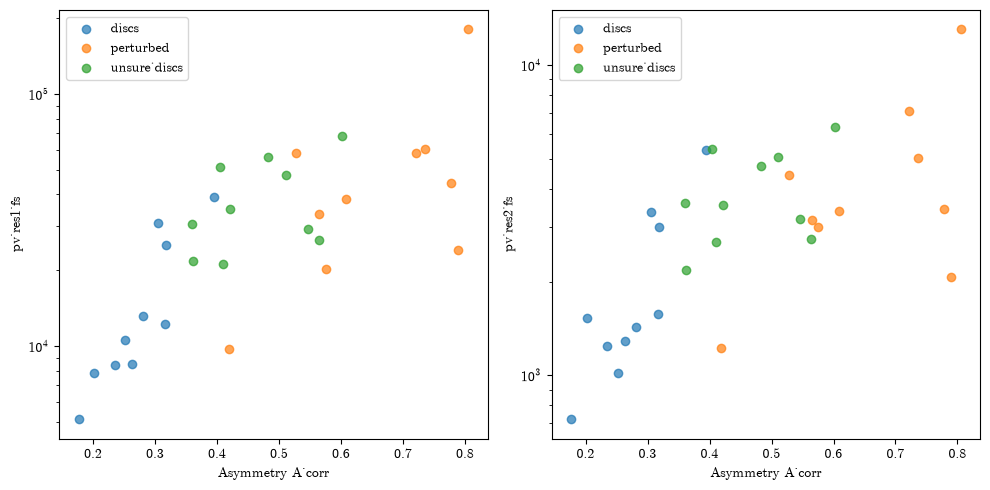

In [6]:
# take cal and plot the PV res1 and res2 vs. asymmetry, with the calibration classes marked in two adjacent plots

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, kind in enumerate(["pv_res1_fs", "pv_res2_fs"]):
    ax = axes[i]
    for cls in sorted(cal["class"].unique()):
        sub = cal[cal["class"] == cls]
        ax.scatter(sub["A_corr"], sub[kind], label=cls, alpha=0.7)
    ax.set_xlabel("Asymmetry A_corr")
    ax.set_yscale("log")
    ax.set_ylabel(kind)
    ax.legend()
fig.tight_layout()
fig.show()

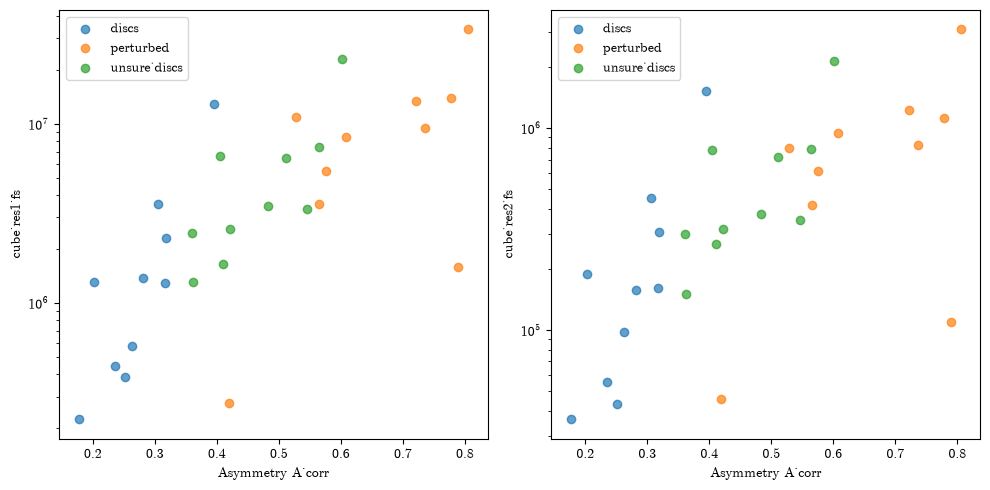

In [7]:
# do the same as above but for the cube res1 and res2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, kind in enumerate(["cube_res1_fs", "cube_res2_fs"]):
    ax = axes[i]
    for cls in sorted(cal["class"].unique()):
        sub = cal[cal["class"] == cls]
        ax.scatter(sub["A_corr"], sub[kind], label=cls, alpha=0.7)
    ax.set_xlabel("Asymmetry A_corr")
    ax.set_yscale("log")
    ax.set_ylabel(kind)
    ax.legend()
fig.tight_layout()
fig.show()

In [8]:
# print subID of highest res2 DISC calibration galaxy

discs = cal[cal["class"].str.lower() == "discs"].sort_values("cube_res1")

print(discs.iloc[-1]["subID"])

81373


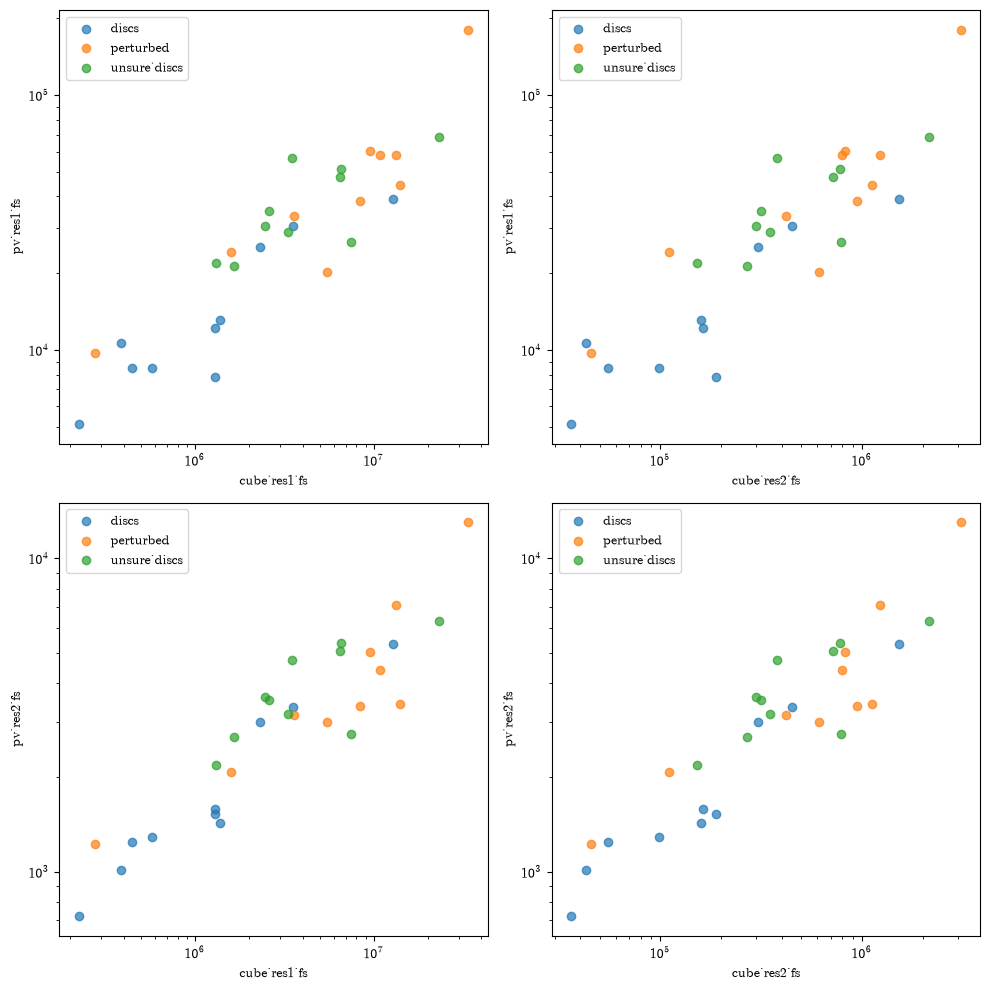

In [9]:
# do 4 plots: PV res vs cube res, for res1 and res2, for the calibration galaxies, with the classes marked in different colors

res = ["res1", "res2"]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i, pv_res in enumerate(res):          # rows: pv res1, pv res2
    for j, cube_res in enumerate(res):    # cols: cube res1, cube res2
        ax = axes[i, j]
        xcol = f"cube_{cube_res}_fs"
        ycol = f"pv_{pv_res}_fs"
        for cls in sorted(cal["class"].unique()):
            sub = cal[cal["class"] == cls]
            ax.scatter(sub[xcol], sub[ycol], label=cls, alpha=0.7)
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.legend()
fig.tight_layout()
fig.show()

In [10]:
# calculate a linear combination of PV res1 and cube res1, and PV res2 and cube res2, for the calibration galaxies

for i, res in enumerate(["res1", "res2"]):
    xcol = f"cube_{res}_fs"
    ycol = f"pv_{res}_fs"
    cal[f"combined_{res}"] = 0.5 * (cal[xcol] + cal[ycol])
    
cal[["model", "z", "subID", "class", "combined_res1", "combined_res2"]]

,model,z,subID,class,combined_res1,combined_res2
0,CDM,0.5,93157,discs,2.925978e+05,4.974968e+04
1,CDM,0.5,93642,discs,1.987076e+05,2.193838e+04
2,CDM,0.5,78273,discs,1.789993e+06,2.273040e+05
3,CDM,0.5,85057,discs,6.552851e+05,8.179141e+04
4,CDM,0.5,89227,discs,1.143673e+05,1.843264e+04
5,CDM,0.5,81373,discs,6.444057e+06,7.634732e+05
6,CDM,0.5,83060,discs,6.548619e+05,9.562315e+04
7,CDM,0.5,85498,discs,1.164978e+06,1.547220e+05
8,CDM,0.5,88029,discs,2.273604e+05,2.826295e+04
9,CDM,0.5,87093,discs,6.946209e+05,8.011167e+04


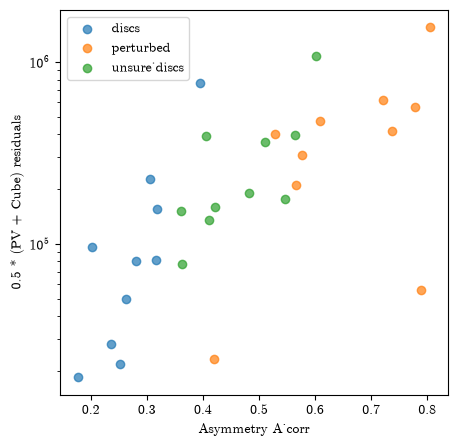

In [11]:
#plot combined (0.5*(res1 + res2)) vs asymmetry for the calibration galaxies, one figure

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for cls in sorted(cal["class"].unique()):
    sub = cal[cal["class"] == cls]
    ax.scatter(sub["A_corr"], sub["combined_res2"], label=cls, alpha=0.7)
ax.set_ylabel("0.5 * (PV + Cube) residuals")
ax.set_xlabel("Asymmetry A_corr")
ax.set_yscale("log")
ax.legend()
fig.show()

In [12]:
#print subID of highest asymmetry DISC calibration galaxy

print(cal[cal["class"].str.lower() == "discs"].sort_values("A_corr").iloc[-1]["subID"])

# print discs subID sorted by asymmetry

print(cal[cal["class"].str.lower() == "discs"].sort_values("A_corr")[["subID", "A_corr"]])

print(cal[cal["class"].str.lower() == "perturbed"].sort_values("A_corr")[["subID", "A_corr"]])

print(cal[cal["class"].str.lower() == "unsure_discs"].sort_values("A_corr")[["subID", "A_corr"]])

81373
   subID    A_corr
4  89227  0.176709
6  83060  0.201927
8  88029  0.235250
1  93642  0.251627
0  93157  0.262961
9  87093  0.280876
2  78273  0.305258
3  85057  0.316567
7  85498  0.318222
5  81373  0.395006
    subID    A_corr
23  87165  0.419293
20  61515  0.527513
22  76974  0.564970
24  54929  0.575775
26  29145  0.608129
28  69646  0.721292
25  59548  0.736151
21  26944  0.777510
29  75244  0.788973
27  35604  0.804902
    subID    A_corr
18  78884  0.360222
14  83990  0.361829
15  79209  0.404550
13  74559  0.410068
16  66519  0.421146
17  83331  0.482798
10  79712  0.510769
12  83086  0.545965
11  84569  0.563859
19  72906  0.601653


In [13]:
from astropy.io import fits
import illustris_python as il
from galaxy_sidm.mock.residuals import cube_noise
from galaxy_sidm.mock.asymmetry import fit_vsys
from galaxy_sidm.mock import load_galaxy_gas, hi_radius_kpc

MODEL_CUT = 1.0 # masked residuals: BBarolo's mask OR model > MODEL_CUT * sigma
X_CACHE = Path("/home2/s4636708/tmp/extra_criteria_all.csv")
X_RECOMPUTE = False # True: recompute X_CACHE
RUNS = {"CDM": "/scratch/s4636708/aida/L35n1080_CDM/output",
        "SIDM1": "/scratch/s4636708/aida/L35n1080_SIDM1/output",
        "vSIDM": "/scratch/s4636708/aida/L35n1080_vSIDM_correa/output"}
Z_SNAP = {float(z): s for s, z in SNAP_Z.items()}
PX_KPC = 5 / 206265 * 5000 # 5 arcsec pixels at 5 Mpc, kpc
MEAN_ABS = np.sqrt(2 / np.pi)


def masked_residuals(model, z, sub, kinds=("pv", "cube")):
    """Per-voxel excess residual in (BBarolo's mask OR model > MODEL_CUT sigma), noise floor removed:
    res1_m = sum (D-M)^2/sig^2 / N - 1,   res2_m = sum |D-M|/sig / N - 0.798."""
    g = gal_dir(model, z, sub)
    bb = g / "bbarolo"
    files = {"pv": (bb / "pvs/MOCK_pv_a.fits", bb / "pvs/MOCKmod_pv_a_azim.fits", bb / "pvs/MOCKmask_pv_a.fits"),
             "cube": (g / "cube.fits", bb / "MOCKmod_azim.fits", bb / "mask.fits")}
    sig = cube_noise(g)
    row = {}
    for kind in kinds:
        row[f"{kind}_res1_m"] = row[f"{kind}_res2_m"] = np.nan
        try:
            D, M, K = (np.asarray(fits.getdata(f), float) for f in files[kind])
        except OSError: # no fit / missing file
            continue
        M, K = np.nan_to_num(M), np.nan_to_num(K)
        use = np.isfinite(D) & ((K != 0) | (M > MODEL_CUT * sig))
        n = int(use.sum())
        if n and np.isfinite(sig):
            d = (D[use] - M[use]) / sig
            row[f"{kind}_res1_m"] = (d ** 2).sum() / n - 1
            row[f"{kind}_res2_m"] = np.abs(d).sum() / n - MEAN_ABS
    return row

def dvsys_offset(model, z, sub):
    """dVsys_halo: BBarolo's V_sys minus the halo's velocity (the cube's central velocity), km/s.
    offset_rel: distance of the moment-0 centroid from the galaxy centre / mean walked extent of the gas."""
    g = gal_dir(model, z, sub)
    bb = g / "bbarolo"
    row = dict(dVsys_halo=np.nan, offset_rel=np.nan)
    try:
        row["dVsys_halo"] = fit_vsys(bb) - fits.getheader(g / "cube.fits")["CRVAL3"] / 1000 # CUNIT3 m/s
        mom0 = np.clip(np.nan_to_num(np.asarray(fits.getdata(bb / "MOCK_mom0th.fits"), float)), 0, None)
    except (OSError, ValueError, KeyError):
        return row
    ext = json.loads((g / "info.json").read_text()).get("extent_arcsec") or [np.nan, np.nan]
    mean_ext = np.mean(ext) / 5 * PX_KPC
    if mom0.sum() > 0 and mean_ext > 0:
        ny, nx = mom0.shape
        yy, xx = np.mgrid[0:ny, 0:nx]
        dx = (mom0 * xx).sum() / mom0.sum() - (nx - 1) / 2
        dy = (mom0 * yy).sum() / mom0.sum() - (ny - 1) / 2
        row["offset_rel"] = float(np.hypot(dx, dy) * PX_KPC / mean_ext)
    return row


def rhi_r50(model, z, sub):
    """R_HI (face-on radius where the neutral H surface density drops to 1 Msun/pc^2, from the particles)
    over the 3D stellar half-mass radius (group catalogue)."""
    base, snap = RUNS[model], Z_SNAP[float(z)]
    gas = load_galaxy_gas(base, snap, sub)
    r50 = float(il.groupcat.loadSingle(base, snap, subhaloID=sub)["SubhaloHalfmassRadType"][4]) * gas.a / gas.h
    return dict(RHI_R50=float(hi_radius_kpc(gas)) / r50)

In [25]:
def one_x(key):
    model, z, sub = key
    return {"model": model, "z": z, "subID": sub, **masked_residuals(model, z, sub),
            **dvsys_offset(model, z, sub), **rhi_r50(model, z, sub)}

with ThreadPoolExecutor(8) as ex:
    cal_x = pd.DataFrame(list(ex.map(one_x, cls_of)))
cal = cal.drop(columns=[c for c in cal_x.columns if c in cal.columns and c not in ("model", "z", "subID")]) # drop duplicates
# cal = cal.drop(columns=["combined_res1", "combined_res2"])
    
# cal[["model", "z", "subID", "class", "combined_res1", "combined_res2"]]
cal = cal.merge(cal_x, on=["model", "z", "subID"], how="left")
for res in ["res1", "res2"]:
    cal[f"combined_{res}_m"] = 0.5 * (cal[f"cube_{res}_m"] + cal[f"pv_{res}_m"])
cal[["subID", "class", "pv_res1_m", "pv_res2_m", "cube_res1_m", "cube_res2_m",
     "combined_res1_m", "combined_res2_m", "dVsys_halo", "offset_rel", "RHI_R50"]].sort_values("class")

,subID,class,pv_res1_m,pv_res2_m,cube_res1_m,cube_res2_m,combined_res1_m,combined_res2_m,dVsys_halo,offset_rel,RHI_R50
0,93157,discs,17.914659,2.349094,20.210136,2.585676,19.062398,2.467385,0.982,0.046254,2.343436
9,87093,discs,20.912858,2.185966,30.211226,3.374321,25.562042,2.780144,-9.828,0.051135,3.427418
7,85498,discs,24.595270,2.843151,22.166928,2.889875,23.381099,2.866513,-3.166,0.029735,3.787280
6,83060,discs,8.410630,1.562239,19.953859,2.604291,14.182245,2.083265,0.833,0.017753,4.188103
5,81373,discs,19.176633,2.559212,26.037178,3.116748,22.606906,2.837980,10.312,0.044440,12.673456
8,88029,discs,14.915621,2.081037,18.554293,2.513254,16.734957,2.297145,-7.249,0.011568,3.338949
3,85057,discs,17.966705,2.430779,25.144345,3.059024,21.555525,2.744902,-6.493,0.080632,6.218145
2,78273,discs,25.770304,2.853714,24.242445,2.949758,25.006375,2.901736,3.185,0.018980,4.629255
1,93642,discs,19.574703,2.505827,14.911700,2.156445,17.243201,2.331136,-13.531,0.060999,3.831061
4,89227,discs,11.409385,1.860411,13.537208,1.976270,12.473297,1.918341,4.367,0.068560,3.453145


In [ ]:
# every galaxy in the manifest: masked PV residuals, dVsys_halo, offset_rel (~6 min once, then cached).
# RHI_R50 needs the particles, so it is only in the calibration cell above.
if X_CACHE.exists() and not X_RECOMPUTE:
    all_x = pd.read_csv(X_CACHE)
else:
    gals = []
    for line in open(MARTINI / "manifest.txt"):
        model, snap, sub = line.split()
        gals.append((model, SNAP_Z[int(snap)], int(sub)))
    with ThreadPoolExecutor(8) as ex:
        all_x = pd.DataFrame(list(ex.map(lambda g: {"model": g[0], "z": g[1], "subID": g[2],
                                                    **masked_residuals(*g, kinds=("pv",)),
                                                    **dvsys_offset(*g)}, gals)))
    all_x.to_csv(X_CACHE, index=False)
allg = allg.drop(columns=[c for c in all_x.columns if c in allg.columns and c not in ("model", "z", "subID")])
allg = allg.merge(all_x, on=["model", "z", "subID"], how="left")
allg

,model,z,subID,logMstar,npix,nradii,extent,at_edge,V,V_over_sigma,...,pv_res3_fs,A,A_noise,A_corr,skipped,class,pv_res1_m,pv_res2_m,dVsys_halo,offset_rel
0,CDM,5.0,229,10.864639,272,18.0,560.000014,False,386.7510,6.913358,...,0.805215,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN
1,CDM,5.0,743,10.742326,138,8.0,245.000006,False,245.8710,2.630514,...,0.831472,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN
2,CDM,5.0,366,10.336362,138,4.0,135.000003,False,252.8090,5.076792,...,0.406690,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN
3,CDM,5.0,1013,10.420739,138,3.0,105.000003,False,258.4575,4.920813,...,0.751202,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN
4,CDM,5.0,1202,10.273508,138,6.0,195.000005,False,306.2790,8.565887,...,0.397245,0.469931,0.125109,0.344822,NaN,,35.002322,3.425395,36.871,0.125697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,vSIDM,0.5,75970,10.151244,336,27.0,815.000020,False,143.6195,20.988820,...,0.449960,0.521668,0.123056,0.398612,NaN,,24.751578,2.835009,3.161,0.005238
4233,vSIDM,0.5,77196,10.292223,266,15.0,475.000011,False,178.7985,17.716730,...,0.371724,0.353815,0.113926,0.239889,NaN,,31.758288,2.731006,2.332,0.031377
4234,vSIDM,0.5,71107,9.807017,398,20.0,605.000015,False,151.3620,12.906532,...,0.590569,0.710473,0.210842,0.499631,NaN,,43.507866,3.791920,14.507,0.226728
4235,vSIDM,0.5,82374,10.132980,280,9.0,290.000007,False,150.9985,10.908807,...,0.312412,0.545323,0.146816,0.398507,NaN,,43.596248,3.593468,-4.678,0.139139


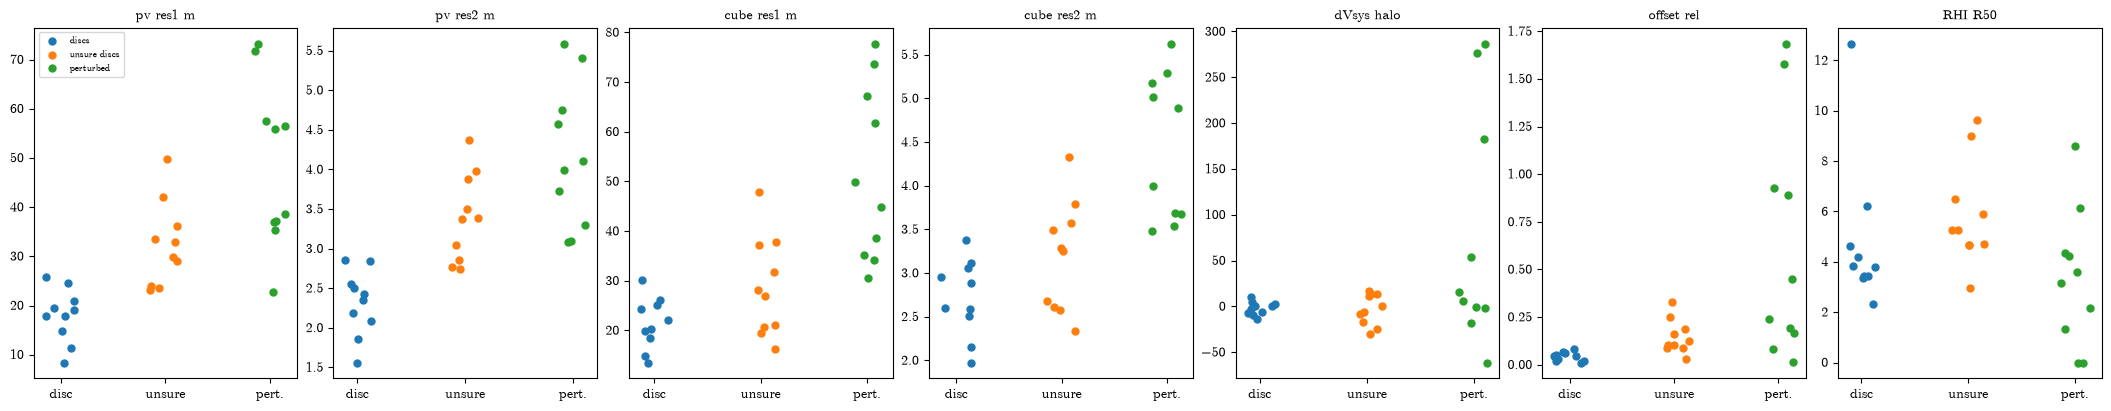

In [ ]:
# each quantity per calibration class
cols = ["pv_res1_m", "pv_res2_m", "cube_res1_m", "cube_res2_m", "dVsys_halo", "offset_rel", "RHI_R50"]
classes = ["discs", "unsure_discs", "perturbed"]
fig, axes = plt.subplots(1, len(cols), figsize=(3 * len(cols), 4), constrained_layout=True)
rng = np.random.default_rng(0)
for ax, col in zip(axes, cols):
    for i, cls in enumerate(classes):
        v = cal.loc[cal["class"] == cls, col].to_numpy(float)
        ax.scatter(i + rng.uniform(-0.15, 0.15, len(v)), v, s=25, label=cls.replace("_", " "))
    ax.set_xticks(range(len(classes)), ["disc", "unsure", "pert."])
    ax.set_title(col.replace("_", " "), fontsize=10)      # the notebook's serif font has no underscore
axes[0].legend(fontsize=7)
plt.show()

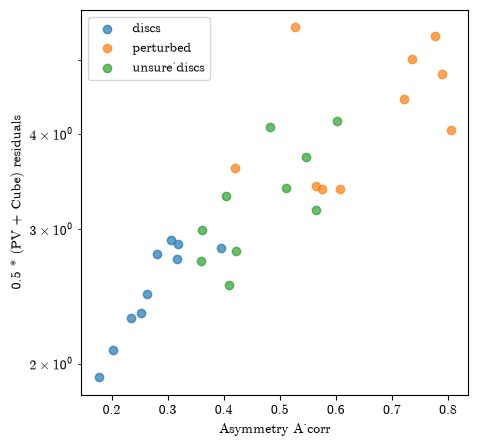

In [27]:
#plot combined (0.5*(res1 + res2)) vs asymmetry for the calibration galaxies, one figure

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for cls in sorted(cal["class"].unique()):
    sub = cal[cal["class"] == cls]
    ax.scatter(sub["A_corr"], sub["combined_res2_m"], label=cls, alpha=0.7)
ax.set_ylabel("0.5 * (PV + Cube) residuals")
ax.set_xlabel("Asymmetry A_corr")
ax.set_yscale("log")
ax.legend()
fig.show()

In [30]:
# print combined res2 value of galaxy 87165

print(cal[cal["subID"] == 87165]["combined_res2_m"].values[0], cal[cal["subID"] == 87165]["A_corr"].values[0])

3.60656561859071 0.4192930062783234
